## Assignment 3: Pattern Mining and Recommender Systems

### Aryan Moradi, A1779263, Version 04

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
from datetime import datetime, timedelta

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
train_path = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data train.csv'
test_path  = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data test.csv'
train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)

In [40]:
# train_path = 'Groceries data train.csv'
# test_path  = 'Groceries data test.csv'
# train_df  = pd.read_csv(train_path)
# test_df   = pd.read_csv(test_path)

# Exploratory Data Analysis (EDA)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import math


import warnings #hide future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Set plot style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

In [42]:

# Check basic info
print(f"Dataset shape: {train_df.shape}")
train_df.head()


Dataset shape: (26985, 7)


,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351.0,1/01/2014,cleaner,2014.0,1.0,1.0,2.0
1,2226.0,1/01/2014,sausage,2014.0,1.0,1.0,2.0
2,1922.0,1/01/2014,tropical fruit,2014.0,1.0,1.0,2.0
3,2943.0,1/01/2014,whole milk,2014.0,1.0,1.0,2.0
4,1249.0,1/01/2014,citrus fruit,2014.0,1.0,1.0,2.0


In [43]:
# Data types and missing values
train_df.info()
print("\nMissing values:")
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26985 entries, 0 to 26984
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_id          19382 non-null  float64
 1   Date             19382 non-null  object 
 2   itemDescription  19382 non-null  object 
 3   year             19382 non-null  float64
 4   month            19382 non-null  float64
 5   day              19382 non-null  float64
 6   day_of_week      19382 non-null  float64
dtypes: float64(5), object(2)
memory usage: 1.4+ MB

Missing values:
User_id            7603
Date               7603
itemDescription    7603
year               7603
month              7603
day                7603
day_of_week        7603
dtype: int64


In [44]:
train_df = train_df.rename(columns={"User_id": "user_id"})

In [45]:
train_df["Date"] = pd.to_datetime(train_df["Date"], format='%d/%m/%Y')

test_df["Date"] = pd.to_datetime(test_df["Date"], format='%d/%m/%Y')

In [46]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train shape: (26985, 7)
Test  shape: (19383, 7)

Columns: ['user_id', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']

Missing values (train):
 user_id            7603
Date               7603
itemDescription    7603
year               7603
month              7603
day                7603
day_of_week        7603
dtype: int64

Missing values (test):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


In [47]:
# Number of unique users and items
print(f"Number of unique users: {train_df['user_id'].nunique()}")
print(f"Number of unique items: {train_df['itemDescription'].nunique()}")

# Count transactions (unique user-date combinations)
transactions = train_df.groupby(['user_id', 'Date'])['itemDescription'].count()
print(f"Number of transactions: {len(transactions)}")
print(f"Average items per transaction: {transactions.mean():.2f}")

Number of unique users: 3493
Number of unique items: 167
Number of transactions: 8361
Average items per transaction: 2.32


=> This initial exploration reveals a medium-sized dataset with a reasonable number of users and a relatively limited product range. The average items per transaction (2.32) indicates that most purchases are quite small - typically 2-3 items per transaction, which is common in grocery or convenience store settings.__

In [48]:
transactions

user_id  Date      
1000.0   2014-06-24    3
1001.0   2014-07-02    3
         2014-12-12    2
         2015-01-20    2
1002.0   2014-04-26    2
                      ..
4997.0   2014-05-01    2
4999.0   2014-05-19    2
         2014-09-04    2
5000.0   2014-09-03    2
         2014-11-16    2
Name: itemDescription, Length: 8361, dtype: int64

In [49]:
transactions.value_counts()

,count
itemDescription,
2,6342
3,1472
4,491
5,26
6,8
8,8
1,5
7,5
9,4


* 6342 transactions contain exactly 2 items (most common)
* 1472 transactions contain 3 items
* 491 transactions contain 4 items
* 26 transactions contain 5 items
* A few transactions contain 6-9 items

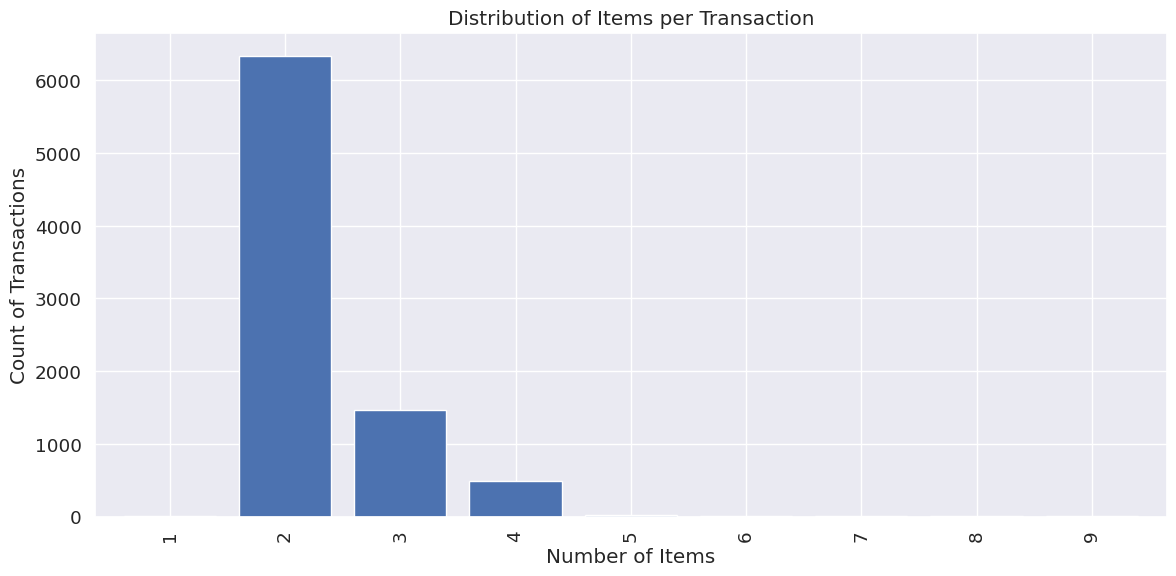

In [50]:
# Distribution of transaction sizes
plt.figure(figsize=(12, 6))
transactions.value_counts().sort_index().plot(kind='bar', width=0.8)
plt.title('Distribution of Items per Transaction')
plt.xlabel('Number of Items')
plt.ylabel('Count of Transactions')
plt.tight_layout()
plt.show()

* This distribution shows a strong preference for a relative small number of items per transactions, which could indicate:
    * This might be a convenience store dataset where customers typically buy only a few items per visit
    * The data might represent quick, frequent shopping trips rather than larger grocery runs
    * Customer behavior tends toward specific item pairs or small combinations rather than varied, large purchases

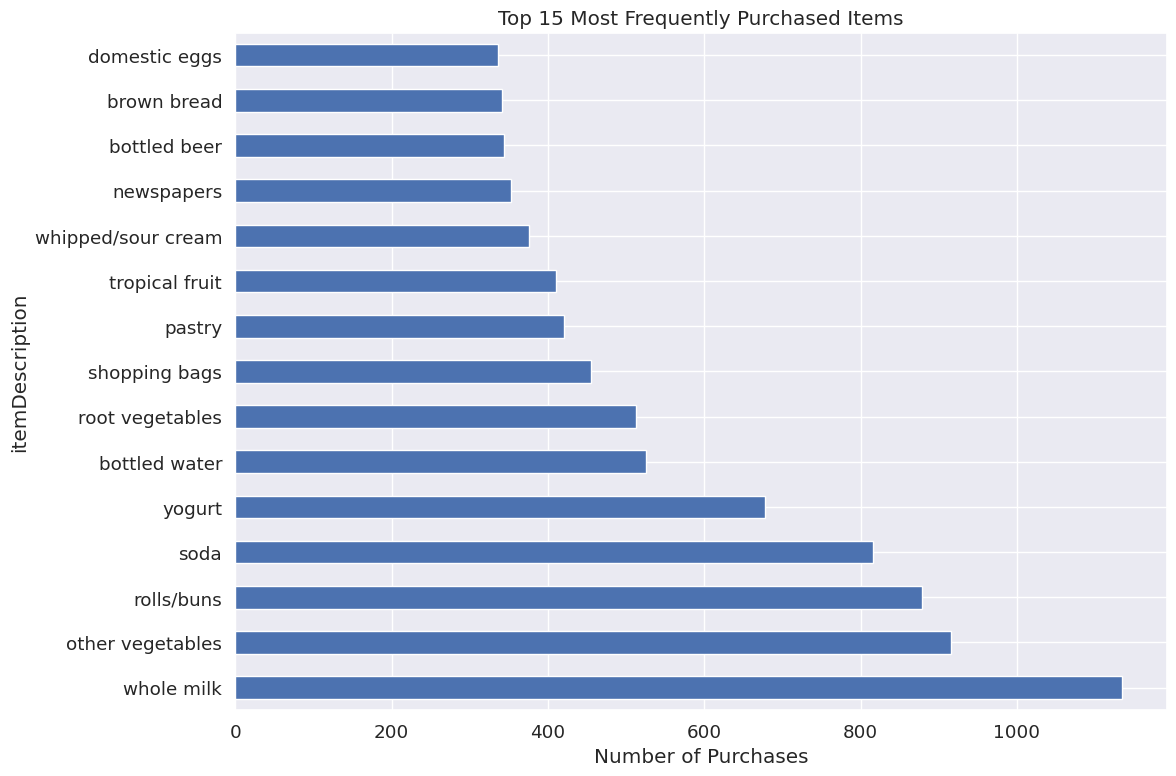

In [51]:
# Most frequent items
item_counts = train_df['itemDescription'].value_counts()
top_items = item_counts.head(15)

plt.figure(figsize=(12, 8))
top_items.plot(kind='barh')
plt.title('Top 15 Most Frequently Purchased Items')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

1. Whole milk is the most bought item with approximately 1,100 purchases, significantly outpacing all other items.
2. Other vegetables and rolls/buns follow as the second and third most popular items, with around 950 and 850 purchases respectively.
3. The data reveals a mix of essentials dominating purchases:
   - Dairy products: whole milk, yogurt, whipped/sour cream
   - Baked goods: rolls/buns, brown bread, pastry
   - Veggies: other vegetables, root vegetables, tropical fruit
   - Beverages: soda, bottled water, bottled beer

4. Essential household items like shopping bags and newspapers also appear in the top 15.
This distribution aligns with typical grocery shopping patterns, where dairy products (especially milk) are purchased frequently. The presence of vegetables, bread products, and beverages suggests this is likely data from a grocery store or supermarket rather than a specialty retailer.
The chart also indicates that the store's strongest categories are dairy, veggies, and bakery items, which could inform inventory management, store layout, and promotional strategies

In [52]:
# Show the percentage of total purchases
print("Top items as percentage of all purchases:")
total = len(train_df)
for item, count in top_items.items():
    print(f"{item}: {count/total*100:.2f}%")

Top items as percentage of all purchases:
whole milk: 4.21%
other vegetables: 3.39%
rolls/buns: 3.25%
soda: 3.02%
yogurt: 2.51%
bottled water: 1.95%
root vegetables: 1.90%
shopping bags: 1.69%
pastry: 1.56%
tropical fruit: 1.52%
whipped/sour cream: 1.39%
newspapers: 1.31%
bottled beer: 1.27%
brown bread: 1.26%
domestic eggs: 1.25%


* Even though whole milk is the most frequently purchased item, it only represents 5.86% of all purchases, indicating a highly diverse product range with purchases spread across many items.
* The top four items (whole milk, other vegetables, rolls/buns, and soda) each account for more than 4% of purchases, making them significantly more popular than other products.
* Despite being in the top 15, even common items like domestic eggs only make up 1.73% of all purchases.
* Together, these top 15 items account for approximately __41.84%__ of all purchases, meaning that the remaining __~58%__ of purchases are spread across the other 152 unique items in the dataset.

In [53]:
# Initial calculation of support of single items
item_frequencies = train_df.drop_duplicates()['itemDescription'].value_counts() # One item can be purchased twice in a single transaction
# calculate and print out top 15 highest Support
pd.DataFrame(item_frequencies/len(transactions)*100).head(15)

,count
itemDescription,
whole milk,13.048678
other vegetables,10.668580
rolls/buns,10.190169
soda,9.460591
yogurt,7.857912
bottled water,6.075828
root vegetables,6.039947
shopping bags,5.274489
pastry,4.963521


#### __Support Threshold Selection Strategy:__
The support values range from 13.05% (whole milk) down to 3.97% (domestic eggs) for the top 15 items, with the remaining 152 items having even lower support values. I believe a Support Threshold lies between 1-3% is a proper setting (for the time being) for these reasons:
* Setting it too high (for example 5%+) would eliminate most items from our analysis, including many potentially interesting association rules
* Setting it too low (e.g. <0.5%) might include very rare items that don't produce meaningful patterns and will significantly increase computational complexity  

Therefore, __a threshold around 2% would be a good balance because:__
* It would include all my top 15 items (which all have >3.9% support)
* It would likely capture between 30-50 items intotal (roughly 20-30% of all unique items)  
It's low enough to discover interesting patterns but high enough to filter out the noise from very rarely purchased items  

It's my assumptions at this current steps, but I may adjust this threshold if:
* There are __too many rules:__ increase to 2.5-3%
* __too few rules:__ decrease to 1-1.5%

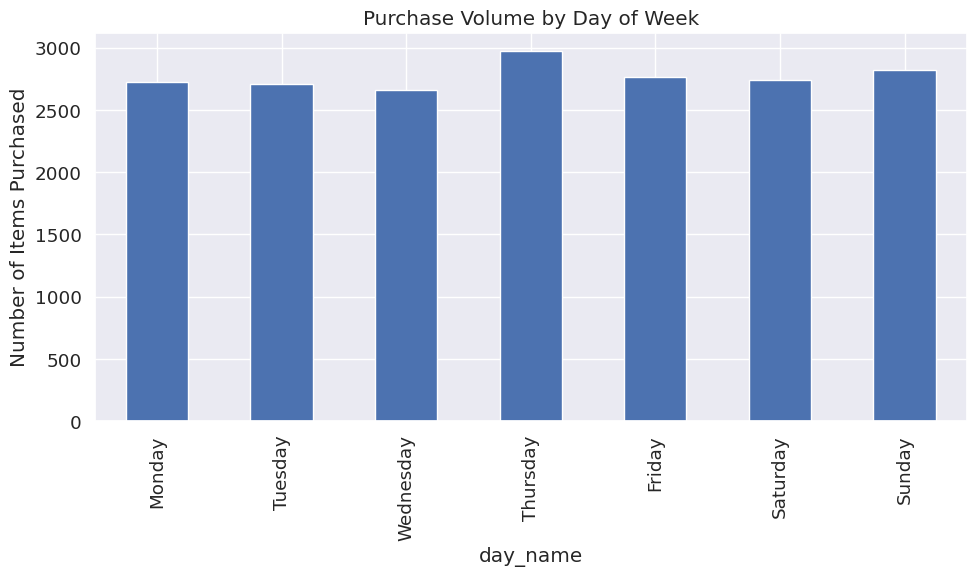

In [54]:
# Purchases by day of week
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
             3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_df['day_name'] = train_df['day_of_week'].map(day_names)

plt.figure(figsize=(10, 6))
train_df['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar')
plt.title('Purchase Volume by Day of Week')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

* Thursday might be popular due to people stocking up before the weekend
* The slight weekend peak (Sunday) could represent major weekly grocery trips
* The relative consistency across days indicates this store maintains steady customer traffic rather than having extreme peaks

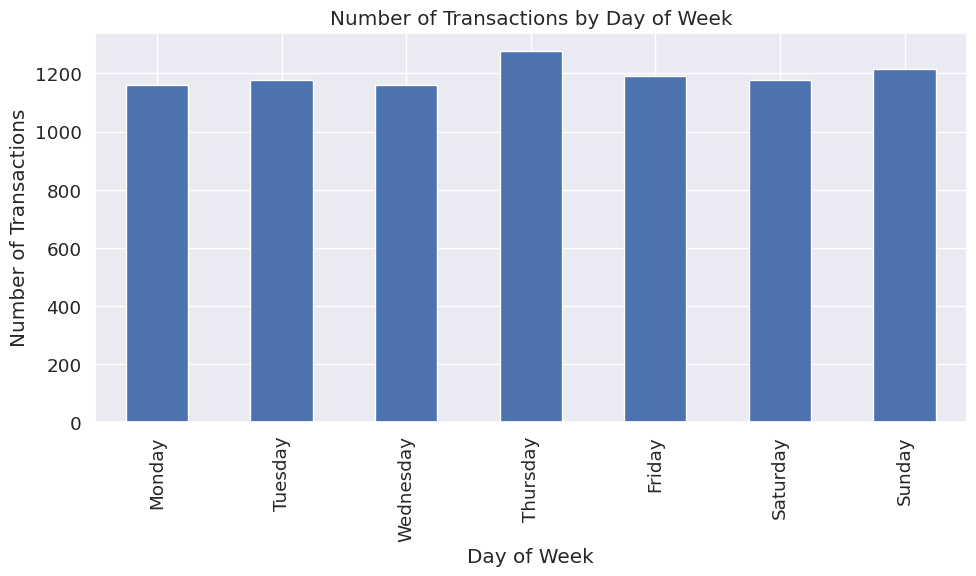

In [55]:
 # Count unique transactions per day
# First, get unique (User_id, Date) combinations with their corresponding day
transaction_days = train_df[['user_id', 'Date', 'day_name']].drop_duplicates()

# Count transactions per day
transactions_per_day = transaction_days['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot
plt.figure(figsize=(10, 6))
transactions_per_day.plot(kind='bar')
plt.title('Number of Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

* The consistency between transaction count and purchase volume suggests that the average basket size is fairly stable across different days
* Thursday's prominence in both metrics confirms it as the most important day for store operations
* While Wednesday has fewer visitors, customers seem to purchase similar amounts per visit compared to other days
* The store experiences remarkably consistent traffic throughout the week, with less than 10% variation between the busiest and slowest days

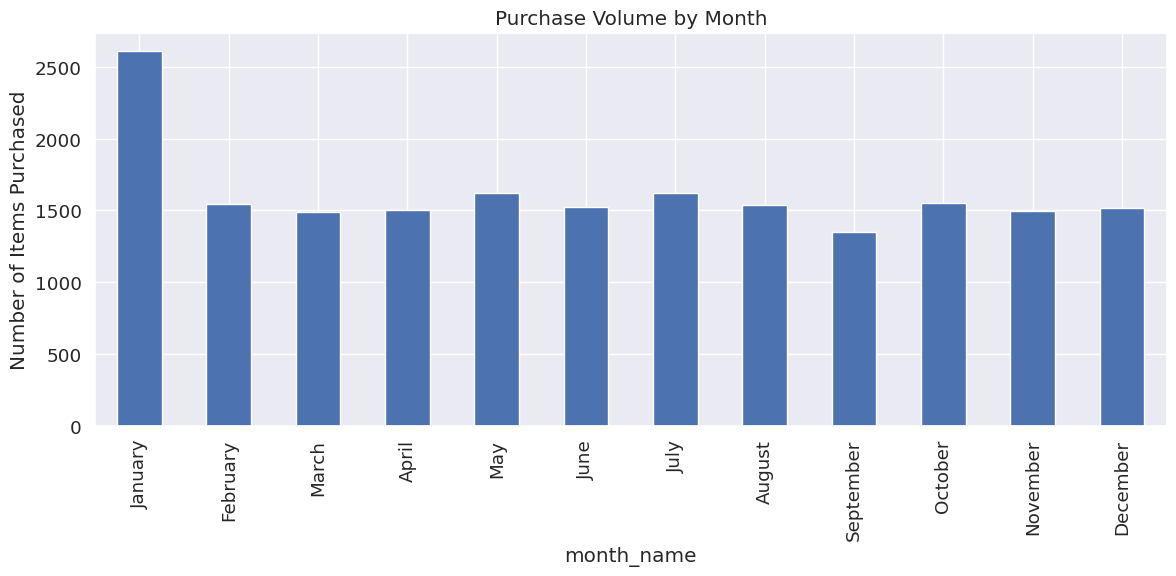

In [56]:
# Purchases by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
# Extract the month name from the 'Date' column and create a new 'month_name' column
train_df['month_name'] = train_df['Date'].dt.month_name()

plt.figure(figsize=(12, 6))
train_df['month_name'].value_counts().reindex(month_order).plot(kind='bar')
plt.title('Purchase Volume by Month')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

* January has a significantly higher number of items purchased compared to other months. This is likely because the data collection period spans from January 1st, 2014 to January 20th, 2015, with a substantial portion of the data coming from the second January (2015). It also potentially captures post-holiday or New Year sale purchases
* The other months show relatively consistent purchase volumes, ranging between approximately 1,400 to 1,600 items per month. However, January stands out with around 2,500 items purchased, which is likely due to the data collection methodology and time range.

In [57]:
train_daily = train_df.groupby('Date').size().reset_index(name='Transactions')
test_daily = test_df.groupby('Date').size().reset_index(name='Transactions')

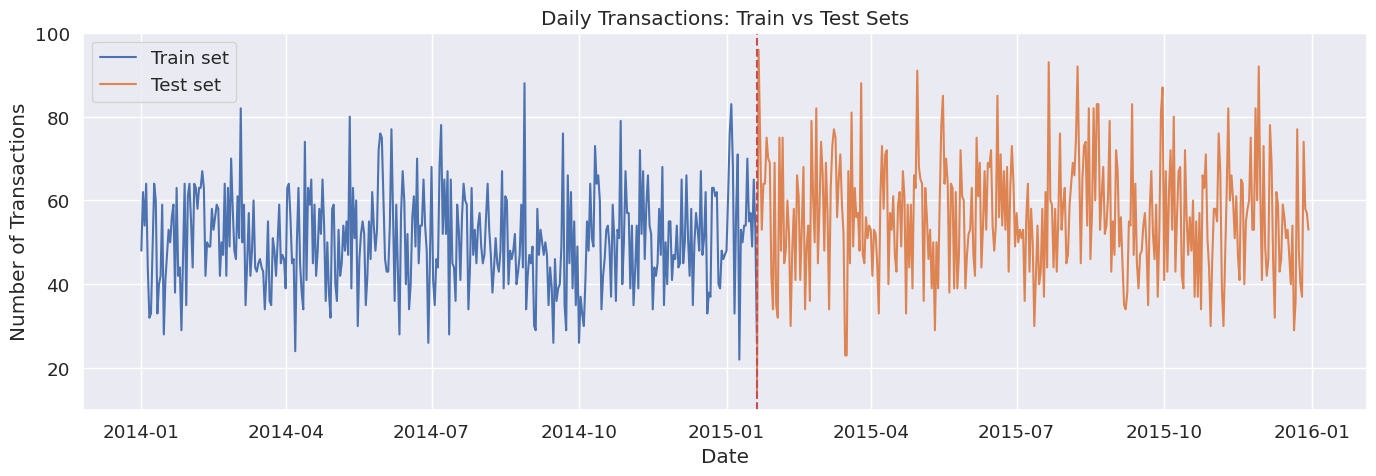

In [58]:
plt.figure(figsize=(14, 5))
plt.plot(train_daily['Date'], train_daily['Transactions'], label='Train set')
plt.plot(test_daily['Date'], test_daily['Transactions'], label='Test set')

plt.title('Daily Transactions: Train vs Test Sets')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.axvline(x=test_daily['Date'].min(), color='r', linestyle='--', label='Train/Test Split')
plt.tight_layout()
plt.show()

In [59]:
top20_train = train_df["itemDescription"].value_counts().head(20)
top20_test  = test_df["itemDescription"].value_counts().head(20)

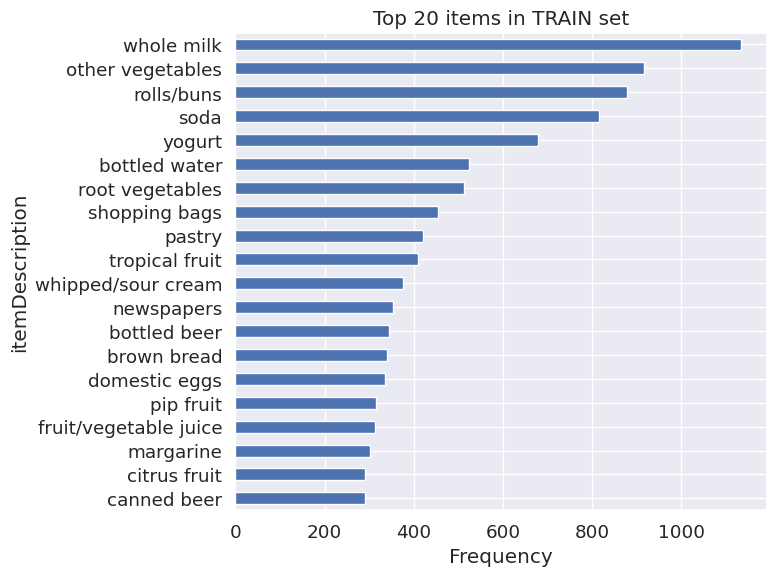

In [60]:
fig, ax = plt.subplots(figsize=(8,6))
top20_train[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 items in TRAIN set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

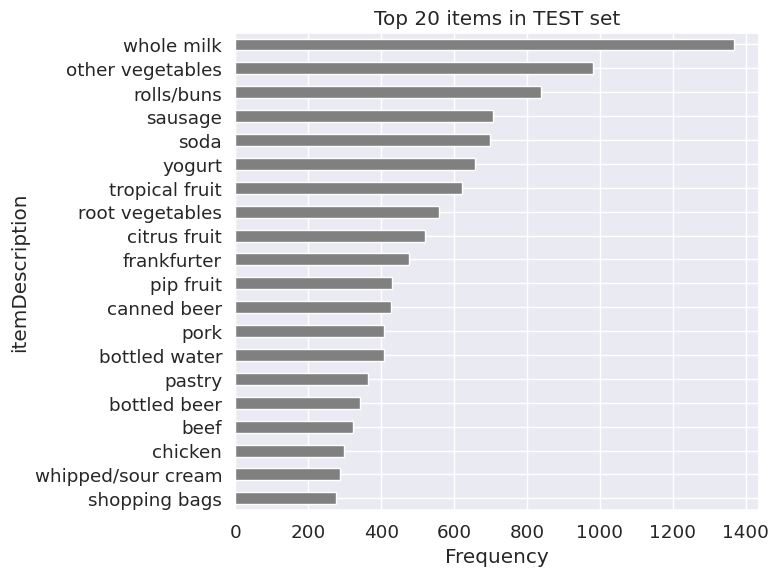

In [61]:
fig, ax = plt.subplots(figsize=(8,6))
top20_test[::-1].plot(kind="barh", ax=ax, color="grey")
ax.set_title("Top 20 items in TEST set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

In [62]:
n_users_train = train_df["user_id"].nunique()
n_users_test  = test_df["user_id"].nunique()
print(f"Unique users in 2014 (train): {n_users_train:,}")
print(f"Unique users in 2015 (test):  {n_users_test:,}")

Unique users in 2014 (train): 3,493
Unique users in 2015 (test):  3,231


In [63]:
items_per_user = train_df.groupby("user_id")["itemDescription"].count()

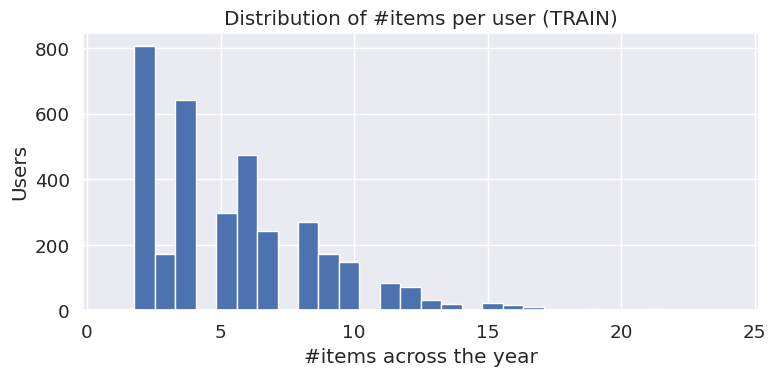

In [64]:
plt.figure(figsize=(8,4))
plt.hist(items_per_user, bins=30)
plt.title("Distribution of #items per user (TRAIN)")
plt.xlabel("#items across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

In [65]:
dow_map = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train_dow = train_df["day_of_week"].value_counts().sort_index()
test_dow  = test_df["day_of_week"].value_counts().sort_index()

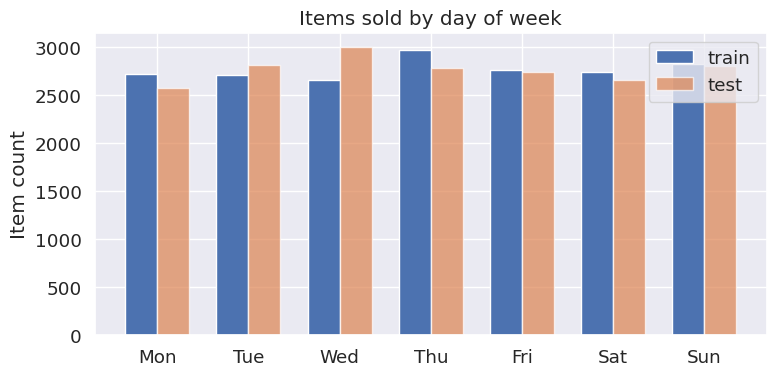

In [66]:
x = np.arange(7)
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, train_dow.values, width, label="train")
ax.bar(x + width/2, test_dow.values,  width, label="test", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(dow_map)
ax.set_title("Items sold by day of week")
ax.set_ylabel("Item count")
ax.legend()
plt.tight_layout()
plt.show()

In [67]:
train_baskets = (
    train_df
      .groupby(["user_id", "Date"])
      .size()
      .reset_index(name="items_in_basket")
)

In [68]:
baskets_per_user = train_baskets.groupby("user_id").size()

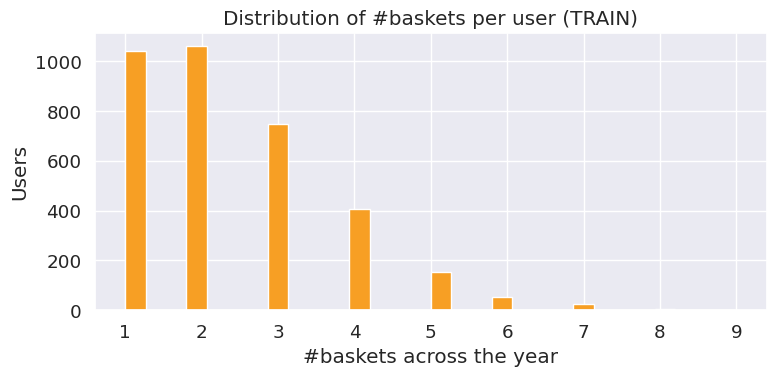

In [69]:
plt.figure(figsize=(8,4))
plt.hist(baskets_per_user, bins=30, color="#F79F24")
plt.title("Distribution of #baskets per user (TRAIN)")
plt.xlabel("#baskets across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

## Frequent Pattern Mininig

In [70]:
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}

    # Find all frequent subsets
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.

        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items

        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)

        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1

        # Filter by minimum support
        min_count = self.min_support * self.num_transactions
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items()
                           if count >= min_count}

        # Initialize L1 (frequent 1-itemsets)
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1

        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1]
        }
        # ========================
        # Main Apriori loop
        while current_L:
            k += 1
            # Generate candidate k-itemsets
            Ck = self._generate_candidates(current_L, k)

            if not Ck:
                break  # No candidates generated

            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1

            # Filter by minimum support
            Lk = [itemset for itemset, count in itemset_counts.items()
                 if count >= min_count]

            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions)
                                           for itemset in Lk]

            # Prepare for next iteration
            current_L = Lk

        return self.frequent_itemsets

    def _generate_candidates(self, prev_itemsets, k):
        """Generate candidate k-itemsets from (k-1)-itemsets"""
        candidates = set()

        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]

        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union: # get subset including (k-1) items from current k-item set
                        subset = union - {item}
                        # If one of the subset of the current set is NOT frequent
                        if frozenset(subset) not in prev_itemsets: #[frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break

                    if is_valid:
                        candidates.add(frozenset(union))
        # Return all sets having k items whose all (k-1) subsets frequent
        return list(candidates)

    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.

        Parameters:
        -----------
        min_confidence : float, default=0.5
            Minimum confidence threshold for rules

        Returns:
        --------
        list
            List of (antecedent, consequent, support, confidence, lift) tuples
        """
        rules = []

        # Helper function to find support for an itemset
        def find_support(itemset):
            k = len(itemset)
            # for k in self.frequent_itemsets:
            for (candidate, support) in self.frequent_itemsets[k]:
                if candidate == itemset:
                    return support
            return 0  # Should not happen for frequent itemsets

        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            # Cannot create rules with a set of only 1 item
            if k < 2:
                continue
            # print('hi')
            for itemset, itemset_support in self.frequent_itemsets[k]:

                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                # print(subsets)
                # For each subset, create a rule
                for antecedent in subsets: # Take the subsets array as array of all entecedents => itemset - antecedent = consequent set
                    consequent = itemset - antecedent

                    # Skip empty consequents
                    if not consequent:
                        continue

                    # A=>B: Calculate CONFIDENCE P(A, B) / P(A)
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support

                    if confidence >= min_confidence:
                        # A= > B: Calculate LIFT P(A, B) /(P(A)*P(B))
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support

                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })

        return rules

In [71]:
class PatternScorer:
    """
    PatternScorer evaluates frequent itemsets from market basket analysis.

    This class provides methods to score patterns using various metrics including
    support, lift, recency, and combinations of these metrics. It can also personalize
    recommendations based on user purchase history.
    """
    def __init__(self, transactions, frequent_itemsets, item_support):
        """
        Initialize the PatternScorer with transaction data and frequent itemsets.

        Parameters:
        -----------
        transactions : list
            List of transactions where each transaction is a set of items
        frequent_itemsets : dict
            Dictionary mapping k (itemset size) to list of (itemset, support) tuples
        item_support : dict
            Dictionary mapping individual items to their support values
        """
        self.transactions = transactions
        self.frequent_itemsets = frequent_itemsets
        self.item_support = item_support
        self.user_data = None

    def add_user_data(self, data):
        """
        Add user-specific data for personalized scoring.

        This method processes user transaction data to calculate:
        1. How frequently each user buys each item
        2. When each user last purchased each item

        Parameters:
        -----------
        data : DataFrame
            DataFrame containing user purchase history with User_id, itemDescription, and Date columns
        """
        self.user_data = data

        # Initialize dictionaries to track user purchase patterns
        # user_item_frequencies: How many times each user bought each item
        self.user_item_frequencies = defaultdict(lambda: defaultdict(int))
        #This dictionary stores user's latest date making purchase on each item
        self.user_last_purchase = defaultdict(lambda: defaultdict(str))

        # Group data by user
        for _, row in data.iterrows():
            user = row['user_id']
            item = row['itemDescription']
            date = row['Date']

            # FOREACH USER FOREACH ITEM: store how many time they purchased that item and the latest purchase date

            # Update frequency
            self.user_item_frequencies[user][item] += 1

            # Update last purchase date if needed (if we found a new record of current user purchasing same item but more recent)
            if item not in self.user_last_purchase[user] or date > self.user_last_purchase[user][item]:
                self.user_last_purchase[user][item] = date

    def score_patterns(self, method='combined', user_id=None, top_n=None):
        """
        Score patterns using various metrics.

        This method calculates scores for itemsets based on the specified method.
        It can personalize scores for specific users and return only top N results.

        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, optional
            If provided, return only top N patterns

        Returns:
        --------
        list
            Scored patterns as (itemset, score) tuples, sorted by score in descending order
        """
        # Create a flat list of all itemsets with their supports
        all_itemsets = []
        if isinstance(self.frequent_itemsets,dict):
            for k in self.frequent_itemsets:
                all_itemsets.extend([(frozenset(itemset), support) for itemset, support in self.frequent_itemsets[k]])

        # Apply scoring method

        #support method
        if method == 'support':
            scored_patterns = [(list(itemset), support) for itemset, support in all_itemsets]

        #lift method
        elif method == 'lift':
            scored_patterns = []
            for itemset, support in all_itemsets:
                if len(itemset) <= 1:
                    # For single items, just use support
                    scored_patterns.append((list(itemset), support))
                else:
                    # Calculate average lift for this pattern
                    avg_lift = self._calculate_pattern_lift(itemset, support)
                    # WEIGHT BY SUPPORT==============
                    # score = avg_lift * support
                    score = avg_lift
                    scored_patterns.append((list(itemset), score))

        #recency method
        elif method == 'recency':
            if user_id is None or self.user_data is None:
                raise ValueError("User ID and user data required for recency scoring")

            scored_patterns = []
            for itemset, support in all_itemsets:
                # Calculate recency score
                recency_score = self._calculate_recency_score(itemset, user_id)
                # Combine with support
                # score = recency_score * support
                score = recency_score
                scored_patterns.append((list(itemset), score))

        # combine confidence + lift + recency (using user data)
        elif method == 'combined':
            # Define weights for different factors
            if user_id:
                w_support = 0.2
                w_lift = 0.2
                w_recency = 0.5
                w_frequency = 0.1
            else:
                w_support = 0.4
                w_lift = 0.3
                w_recency = 0
                w_frequency = 0.3


            scored_patterns = []
            for itemset, support in all_itemsets:
                # Start with support component
                score_components = [support * w_support]

                # Add lift component for multi-item patterns
                if len(itemset) > 1:
                    lift = self._calculate_pattern_lift(itemset, support)
                    score_components.append(lift * w_lift)
                else:
                    # For 1-itemsets, still add the weight
                    score_components.append(w_lift)

                # Add user-specific components if available
                if user_id is not None and self.user_data is not None:
                    # Recency component
                    recency = self._calculate_recency_score(itemset, user_id)
                    score_components.append(recency * w_recency)

                    # Frequency component
                    frequency = self._calculate_frequency_score(itemset, user_id)
                    score_components.append(frequency * w_frequency)
                else:
                    # Without user data, add the weights
                    score_components.extend([w_recency, w_frequency])

                # Calculate final score
                final_score = sum(score_components)
                scored_patterns.append((list(itemset), final_score))

        else:
            raise ValueError(f"Unknown scoring method: {method}")

        # Sort by score (descending)
        scored_patterns.sort(key=lambda x: x[1], reverse=True)

        # Return top N if specified
        if top_n is not None:
            return scored_patterns[:top_n]
        return scored_patterns

    def _calculate_pattern_lift(self, pattern, pattern_support):
        """Calculate average lift across all possible rules from this pattern"""
        if len(pattern) <= 1:
            return 1.0  # No meaningful lift for singleton sets

        lifts = []

        # For each possible rule A -> B from this pattern
        for i in range(1, len(pattern)): #len(antecedent) from 1 to len(pattern) - 1, antecedent cannot be empty
            for antecedent_items in combinations(pattern, i):
                antecedent = frozenset(antecedent_items)
                consequent = pattern - antecedent

                # Find supports
                antecedent_support = self._get_itemset_support(antecedent)
                consequent_support = self._get_itemset_support(consequent)

                if antecedent_support > 0 and consequent_support > 0:
                    # A => B, lift = Supp(A,B)/ (Supp(A) * Supp(B)) = Conf(A,B) / Supp(B)
                    confidence = pattern_support / antecedent_support
                    lift = confidence / consequent_support
                    lifts.append(lift)

        # Return average lift
        return sum(lifts) / len(lifts) if lifts else 1.0

    def _get_itemset_support(self, itemset):
        """Get support for an itemset"""
        if len(itemset) == 1:
            item = list(itemset)[0]
            return self.item_support.get(item, 0)

        # Search in frequent itemsets
        for k in self.frequent_itemsets:
            if k == len(itemset):
                for candidate, support in self.frequent_itemsets[k]:
                    if frozenset(candidate) == itemset:
                        return support

        return 0  # Not found (not frequent)

    def _calculate_recency_score(self, pattern, user_id):
        """Calculate recency score based on how recently user purchased items"""
        if user_id not in self.user_last_purchase:
            return 0  # Default for users with no history

        # Get the latest date a purchase was made by a specific user
        latest_date = max(date for user_dates in self.user_last_purchase.values()
                         for date in user_dates.values())

        # Calculate recency for each item in pattern
        recency_scores = []
        # loop to calculate recency score for this pattern
        for item in pattern:
            if item in self.user_last_purchase[user_id]:
                last_purchase = self.user_last_purchase[user_id][item]
                days_since = (latest_date - last_purchase).days

                # Convert to a normalized score (higher is more recent)
                # Using exponential decay: e^(-days/30)
                recency = 30/(days_since) #math.exp(-days_since)
                recency_scores.append(recency)

        # Return average recency
        return sum(recency_scores) if recency_scores else 0 # / len(recency_scores)

    def _calculate_frequency_score(self, pattern, user_id):
        """Calculate frequency score based on how often user buys these items"""
        if user_id not in self.user_item_frequencies:
            return 0.5  # Default for users with no history

        # Find the maximum frequency across all users and items
        max_freq = max(freq for user_freq in self.user_item_frequencies.values()
                      for freq in user_freq.values())

        # Calculate normalized frequency for each item in pattern
        freq_scores = []
        for item in pattern:
            if item in self.user_item_frequencies[user_id]:
                # Normalize by max frequency
                norm_freq = self.user_item_frequencies[user_id][item] / max_freq
                freq_scores.append(norm_freq)

        # Return average frequency
        return sum(freq_scores) / len(freq_scores) if freq_scores else 0.5

In [72]:
class FrequentPatternMiner:
    """
    A class for mining and scoring frequent patterns from grocery transaction data.
    """

    def __init__(self, min_support=0.005, min_confidence=0.3):
        """
        Initialize the pattern miner.

        Parameters:
        -----------
        min_support : float, default=0.005
            Minimum support threshold (between 0 and 1)
        min_confidence : float, default=0.3
            Minimum confidence threshold for association rules
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.apriori_miner = None
        self.pattern_scorer = None
        self.transactions = None
    def prepare_transactions(self, data):
        """
        Convert raw data to transaction format.

        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data

        Returns:
        --------
        list of lists
            Transactions in the right format for pattern mining
        """
        # Group by user and date
        transactions = defaultdict(list)
        for _, row in data.iterrows():
            key = (row['user_id'], row['Date'])
            if pd.notna(row['itemDescription']):  # Skip null items
                transactions[key].append(row['itemDescription'])

        # Convert to list of lists
        transaction_list = list(transactions.values())
        return transaction_list

    def fit(self, data, user_id=None):
        """
        Mine frequent patterns from the data.

        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        user_id : int, optional
            If provided, focus on this user's data

        Returns:
        --------
        self
        """
        # Prepare transactions
        if user_id is not None:
            # Filter data for specific user
            user_data = data[data['user_id'] == user_id]
            if len(user_data) > 0:
                self.transactions = self.prepare_transactions(user_data)
            else:
                # User has no data, use all data
                self.transactions = self.prepare_transactions(data)
        else:
            self.transactions = self.prepare_transactions(data)

        # Run Apriori
        self.apriori_miner = AprioriMiner(min_support=self.min_support)
        frequent_itemsets = self.apriori_miner.fit(self.transactions)

        # Create pattern scorer
        self.pattern_scorer = PatternScorer(
            self.transactions,
            frequent_itemsets,
            self.apriori_miner.item_support
        )
        self.pattern_scorer.add_user_data(data)

        return self

    def get_patterns(self, method='combined', user_id=None, top_n=10):
        """
        Get scored patterns.

        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, default=10
            Number of patterns to return

        Returns:
        --------
        list
            List of (pattern, score) tuples
        """
        if self.pattern_scorer is None:
            raise ValueError("You must call fit() before get_patterns()")

        return self.pattern_scorer.score_patterns(
            method=method,
            user_id=user_id,
            top_n=top_n
        )

    def get_rules(self, top_n=20):
        """
        Get association rules.

        Parameters:
        -----------
        top_n : int, default=20
            Number of rules to return

        Returns:
        --------
        list
            List of association rules
        """
        if self.apriori_miner is None:
            raise ValueError("You must call fit() before get_rules()")

        rules = self.apriori_miner.generate_rules(min_confidence=self.min_confidence)

        # Sort by lift
        sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

        return sorted_rules[:top_n]

In [73]:
miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.5)

In [74]:
miner.fit(train_df,user_id=None)

In [75]:
# Get top patterns with combined scoring
top_patterns = miner.get_patterns(method='combined', top_n=15)
print("Top 15 patterns with combined scoring:")
for i, (pattern, score) in enumerate(top_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")

Top 15 patterns with combined scoring:
1. ['whipped/sour cream', 'citrus fruit', 'frankfurter', 'dishes'] (score: 178.5405)
2. ['frozen vegetables', 'vinegar', 'grapes'] (score: 32.1123)
3. ['citrus fruit', 'dishes', 'frankfurter'] (score: 17.9583)
4. ['hard cheese', 'other vegetables', 'soda', 'newspapers'] (score: 14.5682)
5. ['honey', 'flower (seeds)'] (score: 12.1597)
6. ['whipped/sour cream', 'dishes', 'frankfurter'] (score: 11.5504)
7. ['jam', 'house keeping products'] (score: 10.0790)
8. ['rolls/buns', 'ham', 'pickled vegetables'] (score: 8.2167)
9. ['brown bread', 'sugar', 'frankfurter'] (score: 7.2719)
10. ['cocoa drinks', 'canned fish'] (score: 7.0793)
11. ['ham', 'soda', 'pickled vegetables'] (score: 6.5300)
12. ['pork', 'flower (seeds)', 'whole milk'] (score: 6.0760)
13. ['newspapers', 'white bread', 'specialty bar'] (score: 6.0405)
14. ['oil', 'cookware'] (score: 6.0334)
15. ['liver loaf', 'processed cheese'] (score: 5.8990)


In [76]:
# Get top association rules
top_rules = miner.get_rules(top_n=100)
print("\nTop 10 association rules by lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")


Top 10 association rules by lift:
1. ['whipped/sour cream', 'frankfurter'] => ['citrus fruit', 'dishes'] (support: 0.0002, confidence: 0.5000, lift: 2090.2500)
2. ['citrus fruit', 'dishes'] => ['whipped/sour cream', 'frankfurter'] (support: 0.0002, confidence: 1.0000, lift: 2090.2500)
3. ['whipped/sour cream', 'dishes'] => ['citrus fruit', 'frankfurter'] (support: 0.0002, confidence: 0.5000, lift: 1393.5000)
4. ['citrus fruit', 'frankfurter'] => ['whipped/sour cream', 'dishes'] (support: 0.0002, confidence: 0.6667, lift: 1393.5000)
5. ['frankfurter', 'dishes'] => ['whipped/sour cream', 'citrus fruit'] (support: 0.0002, confidence: 0.6667, lift: 428.7692)
6. ['frozen vegetables', 'grapes'] => ['vinegar'] (support: 0.0002, confidence: 0.6667, lift: 179.8065)
7. ['whipped/sour cream', 'citrus fruit', 'frankfurter'] => ['dishes'] (support: 0.0002, confidence: 1.0000, lift: 112.9865)
8. ['frozen vegetables', 'vinegar'] => ['grapes'] (support: 0.0002, confidence: 1.0000, lift: 101.9634)
9. 

## Collaborative Filtering

In [77]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['itemDescription'].unique()
print("Number of unique users:", len(unique_users))
print("Number of unique items:", len(unique_items))

Number of unique users: 3494
Number of unique items: 168


In [78]:
min_date = train_df['Date'].min()
max_date = train_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2014-01-01 to 2015-01-20
Total days: 384


In [79]:
min_date = test_df['Date'].min()
max_date = test_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2015-01-20 to 2015-12-30
Total days: 344


In [80]:
def create_user_item_matrix(df, half_life_days=180):
    """
    Create a user-item matrix incorporating recency information using a configurable half-life parameter.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing user-item interactions with timestamp information
    half_life_days : int, optional
        Half-life parameter in days for the recency decay function (default=180)

    Returns:
    --------
    pd.DataFrame
        User-item matrix with recency weights
    """
    # Calculate decay constant lambda based on half-life
    lambda_const = np.log(2) / half_life_days

    # Find the most recent date in the dataset
    max_date = df['Date'].max()

    # Calculate days difference from the most recent date
    days_diff = (max_date - df['Date']).dt.days

    # Add recency information to the dataframe
    df_copy = df.copy()
    df_copy["lambda"] = lambda_const
    df_copy['days_diff'] = days_diff
    df_copy['weight'] = np.exp(-lambda_const * days_diff)

    # Create the user-item matrix using pivot table
    user_item_matrix = pd.pivot_table(
        df_copy,
        values='weight',
        index='user_id',
        columns='itemDescription',
        aggfunc='sum',
        fill_value=0
    )

    return user_item_matrix

In [81]:
def compute_similarities(matrix, method='user'):
    """
    Compute similarities between users or items using cosine similarity.

    Parameters:
    -----------
    matrix : pd.DataFrame
        User-item matrix
    method : str, optional
        Type of similarity to compute - either 'user' or 'item' (default='user')

    Returns:
    --------
    pd.DataFrame
        Similarity matrix
    """
    if method == 'user':
        sim_matrix = cosine_similarity(matrix)
        return pd.DataFrame(sim_matrix, index=matrix.index, columns=matrix.index)
    else:  # item-item
        sim_matrix = cosine_similarity(matrix.T)
        return pd.DataFrame(sim_matrix, index=matrix.columns, columns=matrix.columns)

In [82]:
def generate_recommendations(user_item_matrix, sim_matrix, user_id=None, method='user', top_n=5):
    '''
    Generate recommendations using collaborative filtering based on either user-user or item-item similarity

    Parameters:
    -----------
    user_item_matrix : pd.DataFrame
        Matrix containing user-item interactions with recency weights
    sim_matrix : pd.DataFrame
        Pre-computed similarity matrix (either user-user or item-item)
    user_id : int
        ID of the user to generate recommendations for
    method : str, optional
        Type of collaborative filtering - either 'user' or 'item' (default='user')
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    pd.Series
        Series containing top-n recommended items with their scores
        Returns None if user_id not found or no recommendations possible
    '''

    if method == 'user':
        if user_id not in user_item_matrix.index:
            return None
        similar_scores = sim_matrix.loc[user_id]
        similar_users = similar_scores.nlargest(top_n + 1).index[1:]

        user_items = user_item_matrix.loc[similar_users]
        similar_user_weights = similar_scores[similar_users].values.reshape(-1, 1)
        weight_sum = similar_user_weights.sum()

        weighted_items = pd.Series(
            (user_items.values * similar_user_weights).sum(axis=0) / weight_sum,
            index=user_item_matrix.columns
        )

        user_items = user_item_matrix.loc[user_id]
        weighted_items[user_items > 0] = 0

        return weighted_items.nlargest(top_n)

    else:   # method == 'item'
        if user_id not in user_item_matrix.index:
            return None

        user_vec = user_item_matrix.loc[user_id]
        bought_items = user_vec[user_vec > 0]
        candidates = user_vec[user_vec == 0].index

        scores = {}

        for target in candidates:
            sims = sim_matrix.loc[target, bought_items.index]
            sims_top = sims[sims > 0].sort_values(ascending=False).head(top_n)
            if sims_top.empty:
                continue

            sim_vals   = sims_top.values
            purchase_w = bought_items[sims_top.index].values

            scores[target] = np.dot(sim_vals, purchase_w) / sim_vals.sum()

        if not scores:
            return None

        return (pd.Series(scores).sort_values(ascending=False).head(top_n))

In [83]:
def generate_association_recommendations(rules_df, user_item_matrix, user_id, top_n=5):
    """
    Generate specialized collaborative filtering recommendations using association rules and user-item matrix

    Parameters:
    -----------
    rules_df : pd.DataFrame
        DataFrame containing association rules with columns: antecedent, consequent, support, confidence, lift
    user_item_matrix : pd.DataFrame
        User-item matrix incorporating recency information
    user_id : int
        ID of the user to generate recommendations for
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    list
        List of top-n recommended items sorted by score
    """
    if user_id not in user_item_matrix.index:
        return []
    user_items = set(user_item_matrix.columns[user_item_matrix.loc[user_id] > 0])
    recommendations = defaultdict(float)
    rules_df['antecedent_set'] = rules_df['antecedent'].apply(lambda x: set(x))
    rules_df['consequent_set'] = rules_df['consequent'].apply(lambda x: set(x))

    for _, rule in rules_df.iterrows():
        antecedent_items = rule['antecedent_set']
        consequent_items = rule['consequent_set']

        overlap = antecedent_items.intersection(user_items)
        if len(overlap) > 0:
            overlap_score = len(overlap) / len(antecedent_items)

            for item in consequent_items:
                if item not in user_items:
                    recency_score = user_item_matrix.loc[user_id, list(overlap)].mean() if len(overlap) > 0 else 0
                    rule_score = rule['confidence'] * rule['lift'] * overlap_score
                    final_score = rule_score * (1 + recency_score)
                    recommendations[item] += final_score

    sorted_recommendations = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return sorted_recommendations[:top_n]

In [84]:
def get_most_popular_items(df, top_n=10):
    """
    Get the most popular items based on frequency of purchase

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing purchase data
    top_n : int, optional
        Number of popular items to return (default=10)

    Returns:
    --------
    list
        List of top_n most popular items
    """
    item_counts = df['itemDescription'].value_counts()
    return item_counts.nlargest(top_n).index.tolist()

In [85]:
def chronological_train_validation_split(df, validation_days=90):
    """
    Split data chronologically into training and validation sets.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing transaction data with datetime column 'Date'
    validation_days : int, optional
        Number of days to use for validation (default=90)

    Returns:
    --------
    tuple
        (train_df, validation_df) - DataFrames for training and validation
    """
    df_sorted = df.sort_values('Date')

    max_date = df_sorted['Date'].max()
    cutoff_date = max_date - timedelta(days=validation_days)

    train_df = df_sorted[df_sorted['Date'] <= cutoff_date]
    validation_df = df_sorted[df_sorted['Date'] > cutoff_date]

    return train_df, validation_df

In [86]:
def precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate precision@k metric

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Precision@k value
    """
    if len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))

    # Precision@k = # of relevant items in top-k / k
    return hits / min(k, len(top_k))

In [87]:
def recall_at_k(recommended_items, actual_items, k=10):
    """
    Calculate recall@k metric

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Recall@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))

    # Recall@k = # of relevant items in top-k / # of relevant items
    return hits / len(actual_items)


In [88]:
def hit_rate(recommended_items_list, actual_items_list):
    """
    Calculate hit rate across all users

    Parameters:
    -----------
    recommended_items_list : list of lists
        List containing recommended items for each user
    actual_items_list : list of lists
        List containing actual items for each user

    Returns:
    --------
    float
        Hit rate value
    """
    hits = 0
    for i in range(len(recommended_items_list)):
        if len(set(recommended_items_list[i]) & set(actual_items_list[i])) > 0:
            hits += 1

    return hits / len(recommended_items_list)

In [89]:
def ndcg_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Normalized Discounted Cumulative Gain at k

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        NDCG@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Calculate DCG
    dcg = 0
    for i, item in enumerate(top_k):
        if item in actual_items:
            # Using binary relevance (1 if relevant, 0 if not)
            # Position is i+1 (1-indexed)
            dcg += 1.0 / np.log2(i + 2)  # +2 because i is 0-indexed and log_2(1) is 0

    # Calculate IDCG
    # For IDCG, we assume the best possible ordering:
    # all relevant items at the top positions
    num_relevant = min(len(actual_items), k)
    idcg = sum([1.0 / np.log2(i + 2) for i in range(num_relevant)])

    # Avoid division by zero
    if idcg == 0:
        return 0.0

    # NDCG = DCG / IDCG
    return dcg / idcg

In [90]:
def average_precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Average Precision at k

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Average Precision at k
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    hits = 0
    sum_precisions = 0

    for i, item in enumerate(top_k):
        if item in actual_items:
            hits += 1
            # Precision at current position
            precision_at_i = hits / (i + 1)
            sum_precisions += precision_at_i

    # Average precision = sum of precisions / number of relevant items
    return sum_precisions / min(len(actual_items), k)

In [91]:
def evaluate_recommender(train_df, validation_df, half_life_days, method='user', rules_df=None, top_n=10, k=5):
    """
    Evaluate recommender system performance using various metrics

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_days : int or list
        Half-life parameter(s) to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing evaluation metrics
    """
    # Convert half_life_days to list if it's a single value
    if not isinstance(half_life_days, list):
        half_life_days = [half_life_days]

    # Get unique users in validation set
    val_users = validation_df['user_id'].unique()

    # Group validation data by user to get actual items
    val_user_items = validation_df.groupby('user_id')['itemDescription'].apply(list)

    # Get popular items for cold-start users
    popular_items = get_most_popular_items(train_df, top_n=top_n)

    results = {}

    for half_life in half_life_days:
        # Create user-item matrix with current half-life
        user_item_matrix = create_user_item_matrix(train_df, half_life_days=half_life)

        # Compute similarity matrices
        if method == 'user' or method == 'item':
            sim_matrix = compute_similarities(user_item_matrix, method=method)

        # Collect recommendations and actual items for all users
        all_recommendations = []
        all_actuals = []

        for user_id in val_users:
            # Get actual items for this user
            if user_id in val_user_items:
                actual_items = val_user_items[user_id]
            else:
                # Skip users with no validation items
                continue

            # Generate recommendations
            if method == 'user' or method == 'item':
                # Check if user is in training data
                if user_id in user_item_matrix.index:
                    recs = generate_recommendations(
                        user_item_matrix,
                        sim_matrix,
                        user_id,
                        method=method,
                        top_n=top_n
                    )
                    if recs is not None:
                        recommended_items = recs.index.tolist()
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items

            elif method == 'association':
                if rules_df is None:
                    raise ValueError("rules_df must be provided for association method")

                if user_id in user_item_matrix.index:
                    recs = generate_association_recommendations(
                        rules_df,
                        user_item_matrix,
                        user_id,
                        top_n=top_n
                    )
                    if recs:
                        recommended_items = [item for item, _ in recs]
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items

            all_recommendations.append(recommended_items)
            all_actuals.append(actual_items)

        # Calculate metrics
        precisions = []
        recalls = []
        ndcgs = []
        avg_precisions = []

        for recs, acts in zip(all_recommendations, all_actuals):
            precisions.append(precision_at_k(recs, acts, k))
            recalls.append(recall_at_k(recs, acts, k))
            ndcgs.append(ndcg_at_k(recs, acts, k))
            avg_precisions.append(average_precision_at_k(recs, acts, k))

        # Average metrics
        results[half_life] = {
            'precision@k': np.mean(precisions),
            'recall@k': np.mean(recalls),
            'ndcg@k': np.mean(ndcgs),
            'map@k': np.mean(avg_precisions),
            'hit_rate': hit_rate(all_recommendations, all_actuals)
        }

    return results

In [92]:
def tune_half_life(train_df, validation_df, half_life_range, method='user', rules_df=None, top_n=10, k=5):
    """
    Tune half-life parameter and find optimal value

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_range : list
        Range of half-life values to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    tuple
        (best_half_life, metrics_dict) - Best half-life value and dictionary of all metrics
    """
    results = evaluate_recommender(
        train_df,
        validation_df,
        half_life_range,
        method=method,
        rules_df=rules_df,
        top_n=top_n,
        k=k
    )

    # Find best half-life based on NDCG - choose earliest (smallest) half-life that reaches max value
    max_ndcg = max(results.values(), key=lambda x: x['ndcg@k'])['ndcg@k']
    best_half_life = min([hl for hl in results.keys() if results[hl]['ndcg@k'] >= max_ndcg])


    return best_half_life, results

In [93]:
def compare_methods(train_df, validation_df, half_life, rules_df=None, top_n=10, k=5):
    """
    Compare different recommendation methods

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life : int
        Half-life parameter value to use
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing evaluation metrics for each method
    """
    methods = ['user', 'item']
    if rules_df is not None:
        methods.append('association')

    results = {}

    for method in methods:
        method_results = evaluate_recommender(
            train_df,
            validation_df,
            half_life,
            method=method,
            rules_df=rules_df,
            top_n=top_n,
            k=k
        )
        results[method] = method_results[half_life]

    return results

In [94]:
def test_on_test_set(train_df, test_df, best_half_life, best_method, rules_df=None, top_n=10, k=5):
    """
    Test recommender system on test set using best parameters

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    test_df : pd.DataFrame
        Test data
    best_half_life : int
        Best half-life parameter value
    best_method : str
        Best recommendation method
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing test metrics
    """
    return evaluate_recommender(
        train_df,
        test_df,
        best_half_life,
        method=best_method,
        rules_df=rules_df,
        top_n=top_n,
        k=k
    )[best_half_life]


In [95]:
CF_association_miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.2)

In [96]:
CF_association_miner.fit(train_df,user_id=None)

In [97]:
rules = CF_association_miner.get_rules(top_n=None)
rules_df = pd.DataFrame(rules)

In [98]:
train_subset, validation_df = chronological_train_validation_split(train_df, validation_days=90)
print(f"Train subset shape: {train_subset.shape}")
print(f"Validation shape: {validation_df.shape}")

train_start = train_subset['Date'].min()
train_end = train_subset['Date'].max()
val_start = validation_df['Date'].min()
val_end = validation_df['Date'].max()

split_summary = pd.DataFrame({
    'Dataset': ['Training Set', 'Validation Set'],
    'Start Date': [train_start.strftime('%Y-%m-%d'), val_start.strftime('%Y-%m-%d')],
    'End Date': [train_end.strftime('%Y-%m-%d'), val_end.strftime('%Y-%m-%d')],
    'Duration (days)': [(train_end - train_start).days, (val_end - val_start).days],
    'Number of Records': [len(train_subset), len(validation_df)]
})

print("\nData Split Summary:")
print(split_summary.to_string(index=False))
print("\nNote: Validation set contains 90 days of most recent data")

Train subset shape: (14777, 9)
Validation shape: (4605, 9)

Data Split Summary:
       Dataset Start Date   End Date  Duration (days)  Number of Records
  Training Set 2014-01-01 2014-10-22              294              14777
Validation Set 2014-10-23 2015-01-20               89               4605

Note: Validation set contains 90 days of most recent data


In [99]:
# Tune half-life parameter
half_life_range = [7, 14, 30, 60, 90, 180, 365]

In [100]:
# Test for user-based CF
best_hl_user, user_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='user', top_n=10, k=5
)
print(f"Best half-life for user-based CF: {best_hl_user} days")
print("Results for best half-life:")
for metric, value in user_results[best_hl_user].items():
    print(f"  {metric}: {value:.4f}")

Best half-life for user-based CF: 30 days
Results for best half-life:
  precision@k: 0.0652
  recall@k: 0.1117
  ndcg@k: 0.0948
  map@k: 0.0583
  hit_rate: 0.4390


In [101]:
# Test for item-based CF
best_hl_item, item_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='item', top_n=10, k=5
)
print(f"Best half-life for item-based CF: {best_hl_item} days")
print("Results for best half-life:")
for metric, value in item_results[best_hl_item].items():
    print(f"  {metric}: {value:.4f}")

Best half-life for item-based CF: 30 days
Results for best half-life:
  precision@k: 0.0330
  recall@k: 0.0591
  ndcg@k: 0.0475
  map@k: 0.0287
  hit_rate: 0.2061


In [102]:
best_hl_assoc, assoc_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='association',
    rules_df=rules_df, top_n=10, k=5
)
print(f"Best half-life for association rules: {best_hl_assoc} days")
print("Results for best half-life:")
for metric, value in assoc_results[best_hl_assoc].items():
    print(f"  {metric}: {value:.4f}")

Best half-life for association rules: 365 days
Results for best half-life:
  precision@k: 0.0743
  recall@k: 0.1241
  ndcg@k: 0.1044
  map@k: 0.0638
  hit_rate: 0.5082


In [103]:
best_methods = {
    'user': (best_hl_user, user_results[best_hl_user]),
    'item': (best_hl_item, item_results[best_hl_item]),
    'association': (best_hl_assoc, assoc_results[best_hl_assoc])
}

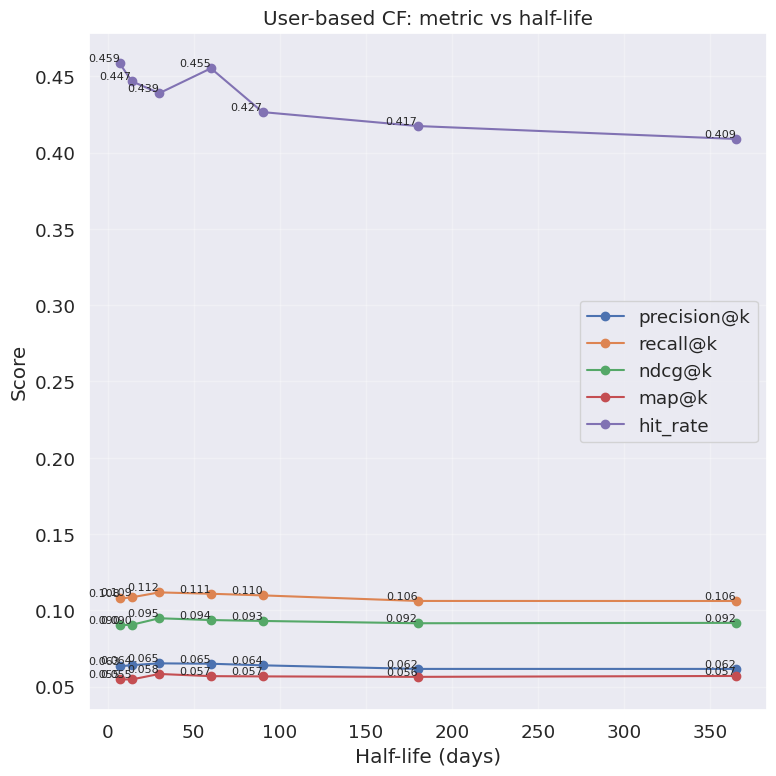

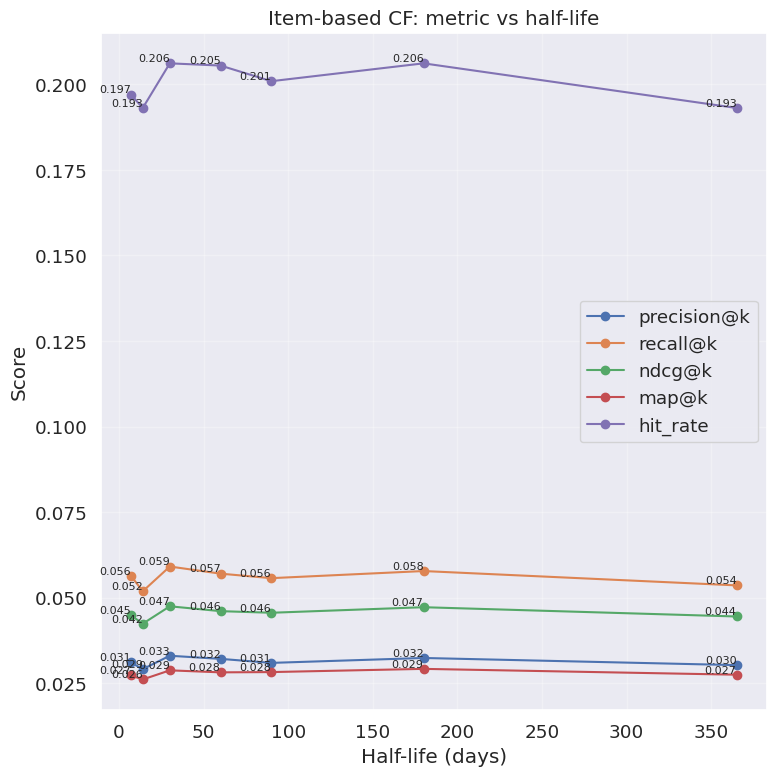

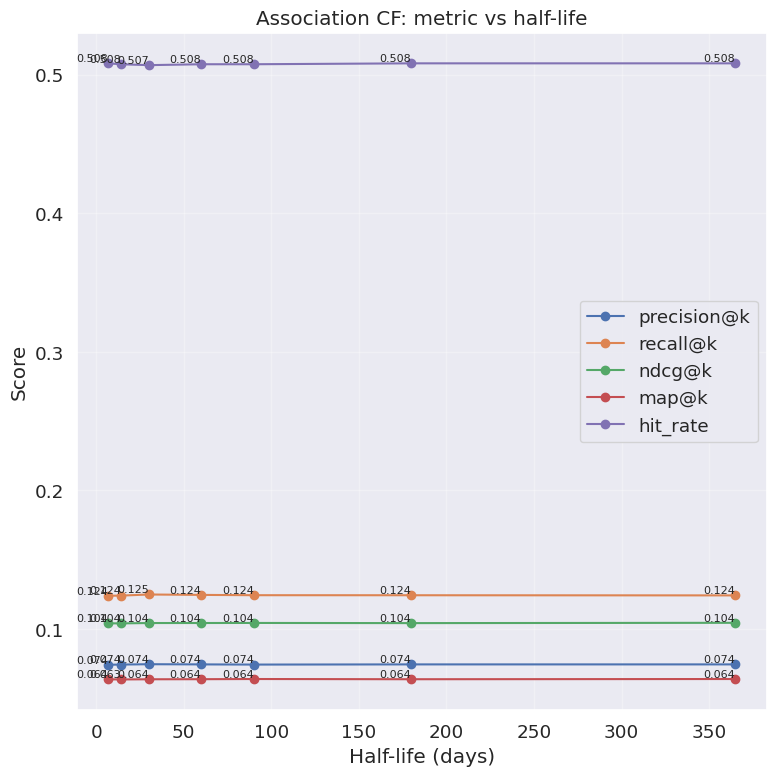

In [104]:
def plot_all_metrics(results_dict, title, metric_order=None, figsize=(8, 8)):
    if metric_order is None:
        metric_order = ['precision@k', 'recall@k',
                        'ndcg@k', 'map@k', 'hit_rate']
    hl_vals = sorted(results_dict.keys())
    plt.figure(figsize=figsize)
    for m in metric_order:
        y = [results_dict[hl][m] for hl in hl_vals]
        plt.plot(hl_vals, y, marker='o', label=m)
        for x_i, y_i in zip(hl_vals, y):
            plt.text(x_i, y_i, f'{y_i:.3f}', fontsize=8,
                     ha='right', va='bottom')
    plt.title(title)
    plt.xlabel('Half-life (days)')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_").replace(":", "")}.png')
    plt.show()

plot_all_metrics(user_results,  "User-based CF: metric vs half-life")
plot_all_metrics(item_results,  "Item-based CF: metric vs half-life")
plot_all_metrics(assoc_results, "Association CF: metric vs half-life")


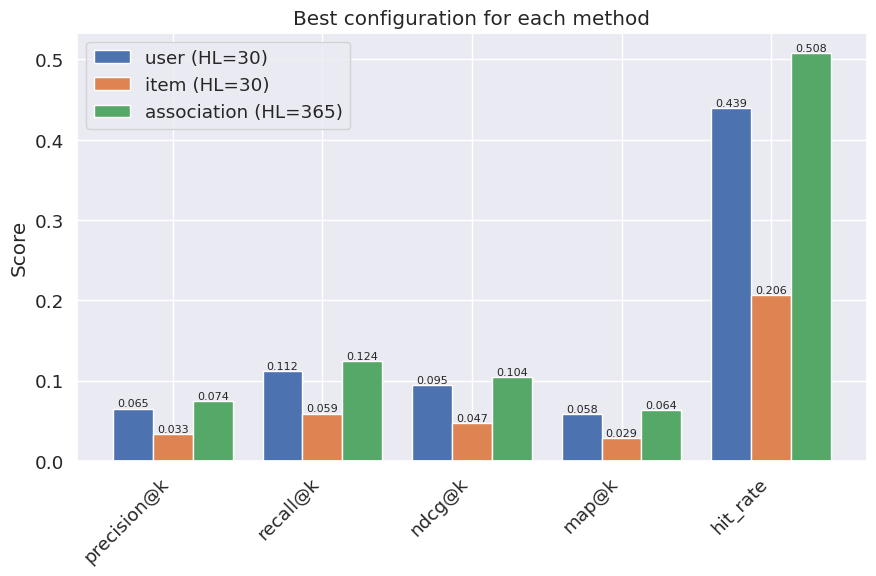

In [105]:
def best_methods_barchart(best_methods, figsize=(9, 6)):
    metrics = ['precision@k', 'recall@k', 'ndcg@k', 'map@k', 'hit_rate']
    methods  = list(best_methods.keys())
    x        = np.arange(len(metrics))
    width    = 0.8 / len(methods)
    plt.figure(figsize=figsize)
    for idx, method in enumerate(methods):
        hl, vals_dict = best_methods[method]
        vals = [vals_dict[m] for m in metrics]
        bars = plt.bar(x + idx*width, vals, width,
                       label=f'{method} (HL={hl})')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    plt.xticks(x + width*(len(methods)-1)/2, metrics, rotation=45, ha='right')
    plt.ylabel('Score')
    plt.title('Best configuration for each method')
    plt.legend()
    plt.tight_layout()
    plt.show()
best_methods_barchart(best_methods)

In [106]:
best_method = max(best_methods.keys(), key=lambda m: best_methods[m][1]['ndcg@k'])
best_half_life = best_methods[best_method][0]

In [107]:
print(f"\nBest method: {best_method}-based with half-life of {best_half_life} days")
print(f"Metrics for best method:")
for metric, value in best_methods[best_method][1].items():
    print(f"  {metric}: {value:.4f}")


Best method: association-based with half-life of 365 days
Metrics for best method:
  precision@k: 0.0743
  recall@k: 0.1241
  ndcg@k: 0.1044
  map@k: 0.0638
  hit_rate: 0.5082


In [108]:
test_results = test_on_test_set(
    train_df, test_df, best_half_life, best_method,
    rules_df=rules_df if best_method == 'association' else None,
    top_n=10, k=5
)

In [109]:
print("\nTest set results:")
for metric, value in test_results.items():
    print(f"  {metric}: {value:.4f}")


Test set results:
  precision@k: 0.1418
  recall@k: 0.1218
  ndcg@k: 0.1559
  map@k: 0.0915
  hit_rate: 0.6936


In [110]:
import time
print("\nTesting all methods on test set:")
test_set_results = {}
for method in best_methods:
    half_life = best_methods[method][0]
    print(f"\nTesting {method}-based method with half-life {half_life}:")

    start_time = time.time()
    results = test_on_test_set(
        train_df, test_df, half_life, method,
        rules_df=rules_df if method == 'association' else None,
        top_n=10, k=5
    )
    end_time = time.time()
    execution_time = end_time - start_time

    test_set_results[method] = {
        'metrics': results,
        'time': execution_time
    }

    print(f"Execution time: {execution_time:.2f} seconds")
    for metric, value in results.items():
        print(f"  {metric}: {value:.4f}")



Testing all methods on test set:

Testing user-based method with half-life 30:
Execution time: 8.60 seconds
  precision@k: 0.1122
  recall@k: 0.0992
  ndcg@k: 0.1305
  map@k: 0.0766
  hit_rate: 0.6168

Testing item-based method with half-life 30:
Execution time: 372.06 seconds
  precision@k: 0.0432
  recall@k: 0.0390
  ndcg@k: 0.0506
  map@k: 0.0310
  hit_rate: 0.2228

Testing association-based method with half-life 365:
Execution time: 80.30 seconds
  precision@k: 0.1418
  recall@k: 0.1218
  ndcg@k: 0.1559
  map@k: 0.0915
  hit_rate: 0.6936


In [111]:
train_df

,user_id,Date,itemDescription,year,month,day,day_of_week,day_name,month_name
0,2351.0,2014-01-01,cleaner,2014.0,1.0,1.0,2.0,Wednesday,January
1,2226.0,2014-01-01,sausage,2014.0,1.0,1.0,2.0,Wednesday,January
2,1922.0,2014-01-01,tropical fruit,2014.0,1.0,1.0,2.0,Wednesday,January
3,2943.0,2014-01-01,whole milk,2014.0,1.0,1.0,2.0,Wednesday,January
4,1249.0,2014-01-01,citrus fruit,2014.0,1.0,1.0,2.0,Wednesday,January
...,...,...,...,...,...,...,...,...,...
26980,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26981,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26982,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26983,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:


user_item_matrix = create_user_item_matrix(train_df, half_life_days=365)
user_item_matrix

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
user_id,,,,,,,,,,,,,,,,,,,,,
1000.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.671127,0.0,0.0
1001.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.610015,0.0,0.0
1002.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.599991,0.0,0.0
1003.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1004.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.148302,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993.0,0.0,0.0,0.740783,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4995.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4997.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.605716,0.0,0.0


In [113]:

popular_items = get_most_popular_items(train_df, top_n=200)
popular_items

['whole milk',
 'other vegetables',
 'rolls/buns',
 'soda',
 'yogurt',
 'bottled water',
 'root vegetables',
 'shopping bags',
 'pastry',
 'tropical fruit',
 'whipped/sour cream',
 'newspapers',
 'bottled beer',
 'brown bread',
 'domestic eggs',
 'pip fruit',
 'fruit/vegetable juice',
 'margarine',
 'citrus fruit',
 'canned beer',
 'butter',
 'coffee',
 'curd',
 'frozen vegetables',
 'white bread',
 'sausage',
 'napkins',
 'chocolate',
 'cream cheese ',
 'dessert',
 'beef',
 'waffles',
 'long life bakery product',
 'UHT-milk',
 'salty snack',
 'sugar',
 'pork',
 'hamburger meat',
 'specialty chocolate',
 'candy',
 'berries',
 'onions',
 'misc. beverages',
 'butter milk',
 'oil',
 'frozen meals',
 'sliced cheese',
 'hygiene articles',
 'chicken',
 'beverages',
 'cat food',
 'hard cheese',
 'specialty bar',
 'ice cream',
 'frankfurter',
 'chewing gum',
 'processed cheese',
 'red/blush wine',
 'pickled vegetables',
 'meat',
 'soft cheese',
 'ham',
 'white wine',
 'flour',
 'grapes',
 'can

In [114]:
user_sim_matrix = compute_similarities(user_item_matrix, method='user')
item_sim_matrix = compute_similarities(user_item_matrix, method='item')

In [115]:

def generate_recommendations(user_item_matrix, sim_matrix, user_id=None, method='user', top_n=5):
    '''
    Generate recommendations using collaborative filtering based on either user-user or item-item similarity

    Parameters:
    -----------
    user_item_matrix : pd.DataFrame
        Matrix containing user-item interactions with recency weights
    sim_matrix : pd.DataFrame
        Pre-computed similarity matrix (either user-user or item-item)
    user_id : int
        ID of the user to generate recommendations for
    method : str, optional
        Type of collaborative filtering - either 'user' or 'item' (default='user')
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    pd.Series
        Series containing top-n recommended items with their scores
        Returns None if user_id not found or no recommendations possible
    '''

    if method == 'user':
        if user_id not in user_item_matrix.index:
            return None
        similar_scores = sim_matrix.loc[user_id]
        similar_users = similar_scores.nlargest(top_n + 1).index[1:]

        user_items = user_item_matrix.loc[similar_users]
        similar_user_weights = similar_scores[similar_users].values.reshape(-1, 1)
        weight_sum = similar_user_weights.sum()

        weighted_items = pd.Series(
            (user_items.values * similar_user_weights).sum(axis=0) / weight_sum,
            index=user_item_matrix.columns
        )

        user_items = user_item_matrix.loc[user_id]
        weighted_items[user_items > 0] = 0

        return weighted_items.nlargest(top_n)

    else:   # method == 'item'
        if user_id not in user_item_matrix.index:
            return None

        user_vec = user_item_matrix.loc[user_id]
        bought_items = user_vec[user_vec > 0]
        candidates = user_vec[user_vec == 0].index

        scores = {}

        for target in candidates:
            sims = sim_matrix.loc[target, bought_items.index]
            sims_top = sims[sims > 0].sort_values(ascending=False).head(top_n)
            if sims_top.empty:
                continue

            sim_vals   = sims_top.values
            purchase_w = bought_items[sims_top.index].values

            scores[target] = np.dot(sim_vals, purchase_w) / sim_vals.sum()

        if not scores:
            return None

        return (pd.Series(scores).sort_values(ascending=False).head(top_n))

In [116]:

def generate_rulebased_recommendations( user_id,train_df=train_df, half_life_days=365, method='association', rules_df=rules_df, top_n=10, k=5, user_item_matrix=user_item_matrix):
    """
    Evaluate recommender system performance using various metrics
                    recommended_items = popular_items
            return recommended_items
            # all_recommendations.append(recommended_items)
            # all_actuals.append(actual_items)

    validation_df : pd.DataFrame
        Validation data
    half_life_days : int or list
        Half-life parameter(s) to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing evaluation metrics
    """



    val_users = [user_id]
    for user_id in val_users:
        # print(user_id)
        if rules_df is None:
            raise ValueError("rules_df must be provided for association method")
        # print(user_item_matrix)
        if user_id in user_item_matrix.index:
            recs = generate_association_recommendations(
                rules_df,
                user_item_matrix,
                user_id,
                top_n=top_n
            )
            # print('recs', recs)
            if recs:
                return recs
                recommended_items = [item for item, _ in recs]
            else:
                recommended_items = popular_items
            return recommended_items
        else:
            # Cold-start: recommend popular items
            recommended_items = popular_items
            return recommended_items


In [117]:
generate_recommendations(user_item_matrix, user_sim_matrix, user_id=1004, method='user', top_n=5)

,0
itemDescription,
yogurt,0.240572
curd,0.192162
cream cheese,0.143516
brandy,0.142159
specialty bar,0.142159


In [118]:
generate_recommendations(user_item_matrix, item_sim_matrix, user_id=1004, method='item', top_n=5)

,0
baby cosmetics,1.646280
female sanitary products,1.485304
potato products,1.435919
cleaner,1.432253
margarine,1.431521


In [119]:
generate_rulebased_recommendations(user_id = 1004, top_n = 5)

[('soda', np.float64(61.04721601219927)),
 ('newspapers', np.float64(49.21682773270797)),
 ('domestic eggs', np.float64(42.120693961214585)),
 ('sausage', np.float64(27.932714761987057)),
 ('yogurt', np.float64(25.690351846029817))]

In [ ]:
def get_recommendation_input():
    """
    Get user input for recommendation system:
    - User ID (integer)
    - Method (1, 2, or 3) corresponding to 'user', 'item', or 'association'
    - 0 to exit
    """
    while True:
        try:
            user_id = int(input("Enter user ID (integer) or 0 to exit: "))

            if user_id == 0:
                print("Exiting the recommendation system.")
                break

            method = int(input("Enter method (1: User-based, 2: Item-based, 3: Association-based): "))

            if method not in [1, 2, 3]:
                print("Invalid method choice. Please enter 1, 2, or 3.")
                continue

            method_name = {1: "User-based", 2: "Item-based", 3: "Association-based"}
            print(f"Selected: User ID = {user_id}, Method = {method_name[method]}")
            res = None
            if method == 1:
                res = generate_recommendations(user_item_matrix, user_sim_matrix, user_id, method='user', top_n=5)

            elif method == 2:
                res = generate_recommendations(user_item_matrix, item_sim_matrix, user_id, method='item', top_n=5)
            else:
                res = generate_rulebased_recommendations(user_id, top_n = 5)

            # Since 'res' is a list, print it directly
            print("Recommended items: ", res) # Print the list of recommended items

        except ValueError:
            print("Please enter valid integer values.")

# Run the input function
get_recommendation_input()

Enter user ID (integer) or 0 to exit: 1169
Enter method (1: User-based, 2: Item-based, 3: Association-based): 3
Selected: User ID = 1169, Method = Association-based
Recommended items:  [('citrus fruit', np.float64(1454.944707027618)), ('dishes', np.float64(941.2385181992945)), ('frankfurter', np.float64(639.3370549127129)), ('hard cheese', np.float64(60.810911245188194)), ('sausage', np.float64(30.92988077673779))]
Enter user ID (integer) or 0 to exit: 3321
Enter method (1: User-based, 2: Item-based, 3: Association-based): 3
Selected: User ID = 3321, Method = Association-based
Recommended items:  [('brown bread', np.float64(19.31021723832237)), ('bottled water', np.float64(15.325677286015813)), ('ham', np.float64(14.484547090783314)), ('newspapers', np.float64(13.600775752553123)), ('pickled vegetables', np.float64(13.539902715297448))]
Enter user ID (integer) or 0 to exit: 1169
Enter method (1: User-based, 2: Item-based, 3: Association-based): 1
Selected: User ID = 1169, Method = User